In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from western_us_biomass import dir_info
from western_us_biomass.make_figures import figure_settings

# Load data

In [2]:
cmip_tseries = xr.open_dataset("figure_data/figure_5/CMIP_tseries2.nc")

In [3]:
df_all_westwide = pd.read_csv("figure_data/figure_2/OurStudy_western_stocks.csv")
western_stocks = pd.read_csv("figure_data/figure_2/USFS_western_stocks.csv")
western_stocks = western_stocks.rename(columns={"Unnamed: 0": "year", "0": "live_biomass_MMT"})

In [4]:
biomass_mean_west = df_all_westwide["live_biomass_MMT"].groupby(df_all_westwide["year"]).median()
biomass_min_west = (
    df_all_westwide["live_biomass_MMT"].groupby(df_all_westwide["year"]).quantile(0.025)
)
biomass_max_west = (
    df_all_westwide["live_biomass_MMT"].groupby(df_all_westwide["year"]).quantile(0.975)
)

biomass_mean_west_delta = (
    df_all_westwide["live_biomass_MMT_delta"].groupby(df_all_westwide["year"]).median()
)
biomass_min_west_delta = (
    df_all_westwide["live_biomass_MMT_delta"].groupby(df_all_westwide["year"]).quantile(0.025)
)
biomass_max_west_delta = (
    df_all_westwide["live_biomass_MMT_delta"].groupby(df_all_westwide["year"]).quantile(0.975)
)

In [5]:
tseries_df = xr.open_dataset("figure_data/figure_5/Liu_tseries.nc")
tseries_Liu = tseries_df["Liu_biomass"]

In [6]:
trends_df = pd.read_csv("figure_data/figure_5/Li_trends.csv")
trend1_westwide = trends_df["trend"].values[0]
startyr1 = trends_df["year_start"].values[0]
endyr1 = trends_df["year_end"].values[0]
trend2_westwide = trends_df["trend"].values[1]
startyr2 = trends_df["year_start"].values[1]
endyr2 = trends_df["year_end"].values[1]

In [7]:
cmip_times = cmip_tseries["change_since_2005"].year.values

p10 = cmip_tseries["change_since_2005"].quantile(0.1, dim="ensemble_member")
p50 = cmip_tseries["change_since_2005"].mean(dim="ensemble_member")
p90 = cmip_tseries["change_since_2005"].quantile(0.9, dim="ensemble_member")

# Make figure

In [8]:
color_CMIP = figure_settings.color_CMIP
color_Liu = figure_settings.color_Liu
color_this_study = figure_settings.color_this_study
color_Li = figure_settings.color_Li
color_EPA = figure_settings.color_EPA

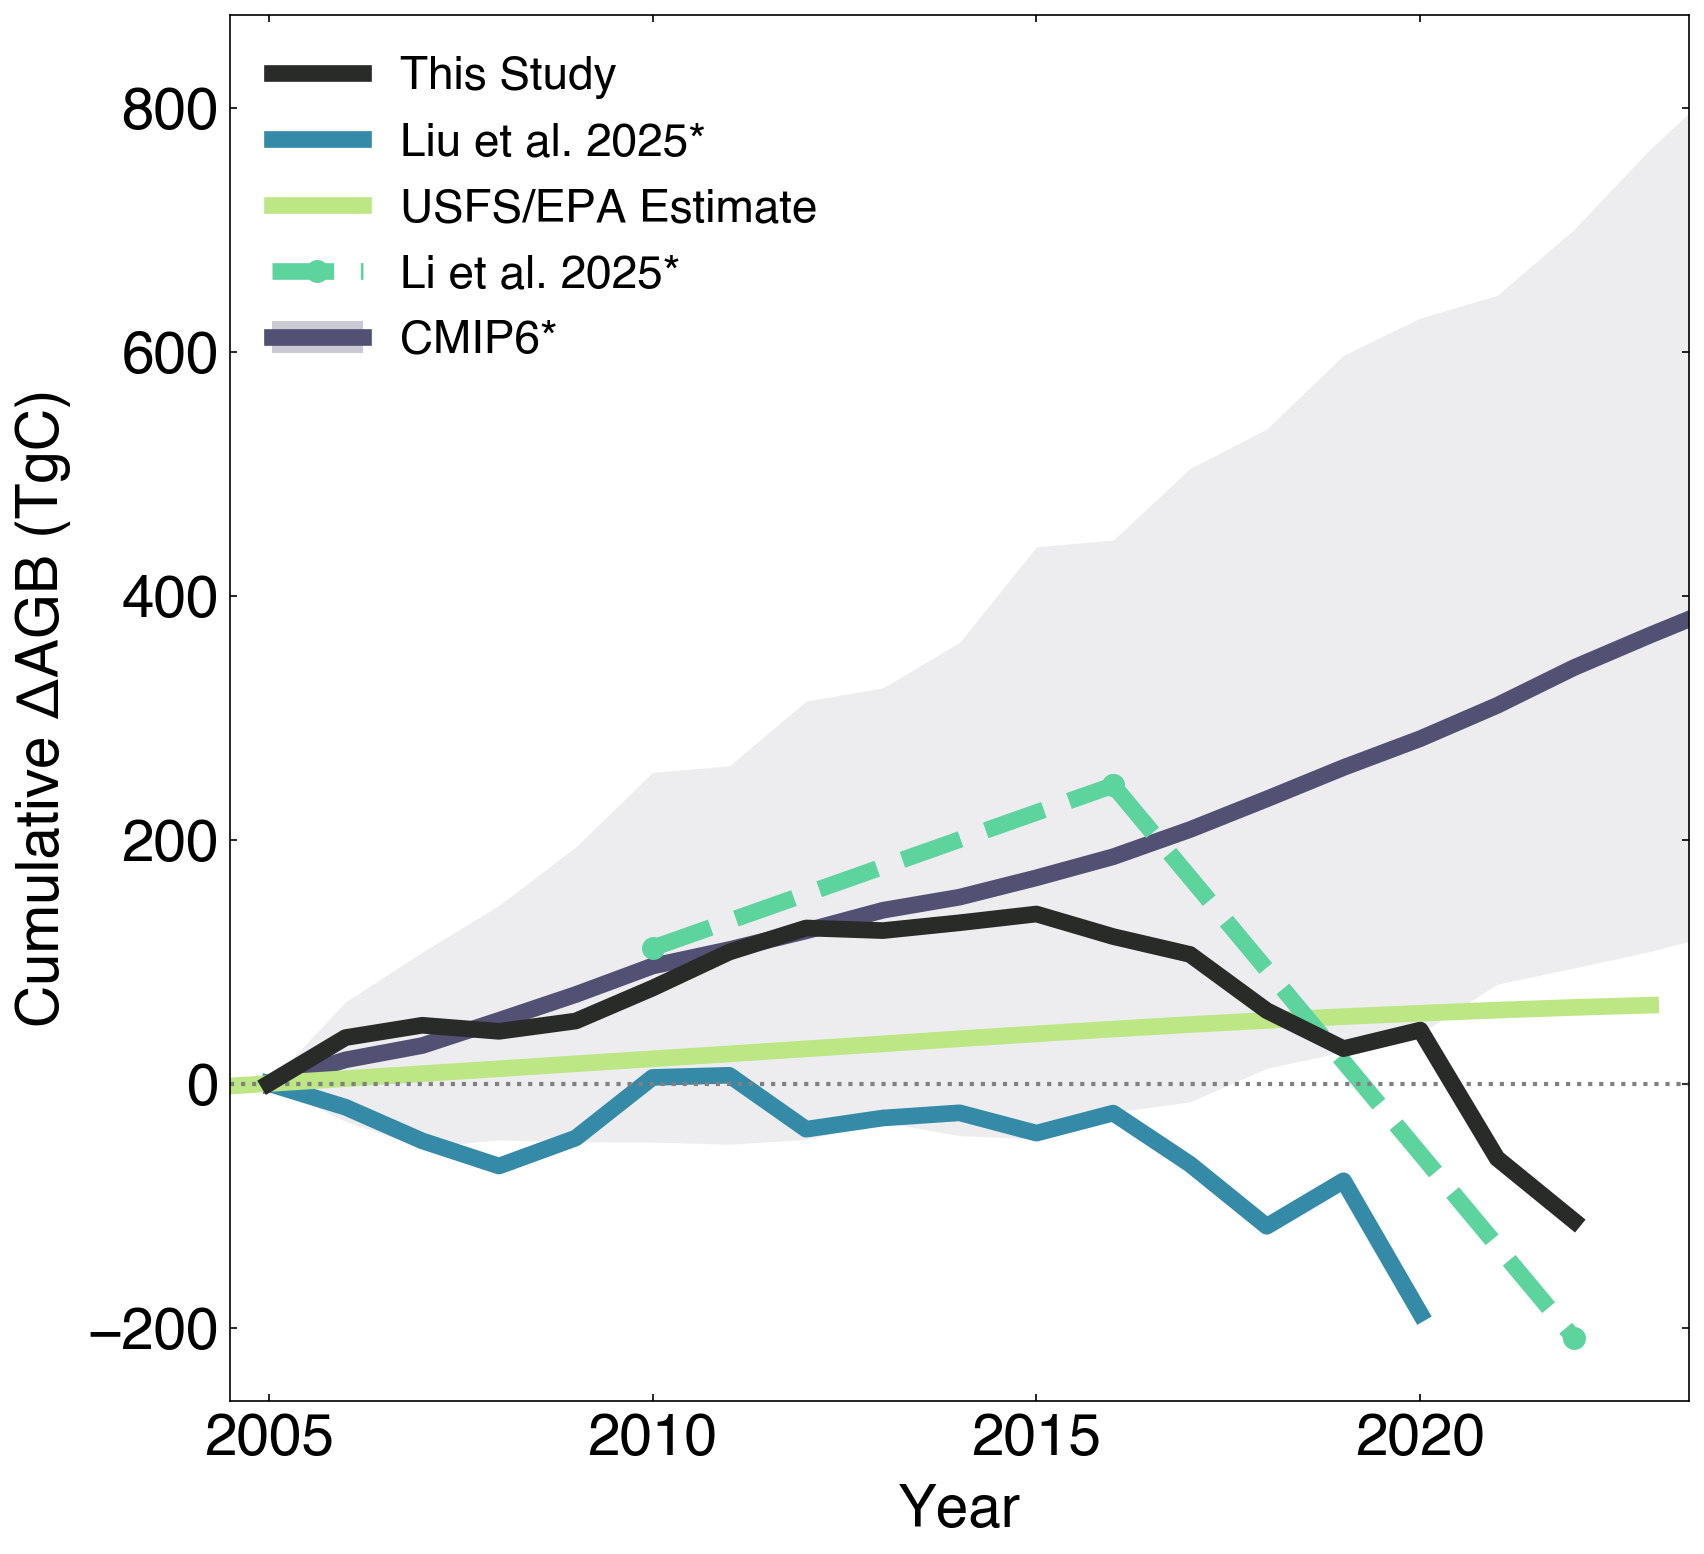

In [9]:
figure_settings.apply_style()

plt.figure(figsize=(12, 11))

plt.plot(
    biomass_mean_west.index,
    (np.array(biomass_mean_west)) - (np.array(biomass_mean_west))[0],
    ".-",
    color=color_this_study,
    label="This Study",
    zorder=10,
)

plt.fill_between(cmip_times, p10, p90, color=color_CMIP, alpha=0.1, linewidth=0)
plt.plot(cmip_times, p50, color=color_CMIP)

plt.plot(
    np.arange(2005, 2021),
    tseries_Liu - tseries_Liu[0],
    label="Liu et al. 2025*",
    color=color_Liu,
)
plt.plot(
    western_stocks["year"],
    western_stocks["live_biomass_MMT"] - western_stocks["live_biomass_MMT"][15],
    "-",
    color=color_EPA,
    label="USFS/EPA Estimate",
)
plt.plot(
    [2010, 2016],
    [trend1_westwide * 5, trend1_westwide * 11],
    "--.",
    color=color_Li,
    markersize=20,
)
plt.plot(
    [2016, 2022],
    [trend1_westwide * 11, trend1_westwide * 11 + trend2_westwide * 6],
    "--.",
    color=color_Li,
    markersize=20,
    label="Li et al. 2025*",
)
plt.xlim([2004.5, 2023.5])
plt.axhline(
    y=0,
    linestyle=":",
    color="gray",
    linewidth=figure_settings.style_settings["lines.linewidth"] / 4,
)
cmip_handle = (
    Patch(facecolor=color_CMIP, alpha=0.3, linewidth=0),
    Line2D([0], [0], color=color_CMIP),
)
handles, labels = plt.gca().get_legend_handles_labels()
handles = handles + [cmip_handle]
labels = labels + ["CMIP6*"]
plt.legend(handles, labels, framealpha=False)
plt.ylabel("Cumulative ΔAGB (TgC)")

ax = plt.gca()
ax.set_xticks(np.arange(2005, 2024, 5))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.set_xlabel("Year")

plt.tight_layout()
# plt.savefig(dir_info.dir_figures + "Figure5.jpg")
# plt.savefig(dir_info.dir_figures + "Figure5.pdf")
plt.savefig(dir_info.dir_figures + "fig-dataset-comparison.jpg")
plt.savefig(dir_info.dir_figures + "fig-dataset-comparison.pdf")